# COMP4381 – Data Science

**Group Name:** SMA

| Name | ID |
|---|---|
| Ahmad Toffaha | 1220476 |
| Mohammad Rjoub | 1220929 |
| Shahad Barmawe | 1210723 |

**Instructor:** Dr. Ahmad Sabbah  
**Section:** 1  
**Date:** 27/5/2026

---

## 1. Dataset Description

The dataset used in this project focuses on airport punctuality and delays across European airports. Each record represents an airport-day observation — each row is related to a specific airport on a specific date. This structure makes the data easier to manage and analyze while providing useful insights into delay patterns over time.

The final dataset contains **5,000 airport-day records** with **19 features** after cleaning and feature engineering.

---

## 2. Data Sources

### EUROCONTROL Daily Airport Punctuality Data

The primary dataset was sourced from EUROCONTROL airport punctuality statistics. It contains daily airport performance information, including:

- Departure Punctuality Percentage
- Arrival Punctuality Percentage
- Average Departure Schedule Delay
- Average Arrival Schedule Delay
- Operated Schedules Percentage

These variables represent airport performance and form the basis of the analysis.

### Weather API

A weather API was used to enrich the dataset with weather-related features. Since weather is a major factor in airport punctuality and flight delays, the API data was collected and merged with the dataset during the preprocessing stage.

---

## 3. Data Cleaning and Preprocessing

Multiple preprocessing steps were applied to improve data quality and prepare the dataset for analysis.

### Data Cleaning

- Converted the date column to `datetime` format
- Verified and corrected numerical columns related to punctuality and schedule delays
- Added a country column by mapping each airport to its corresponding country
- Checked for and removed duplicate records
- Checked for missing values across all columns
- Collected weather data from an external API and merged it into the dataset
- Selected 5,000 rows for the final dataset

After cleaning, the dataset contains **no missing values**.

### Data Transformation

The following features were engineered and added to the dataset:

- Month
- Weekday
- Weekday Name
- Is Weekend
- Season
- Airport Size
- Temperature
- Precipitation
- Wind Speed

These features support the data analysis and model building stages.

---

## 4. Data Summarization

The final dataset contains **5,000 airport-day records** and **19 features**, covering airport performance, date/time data, weather information, and a target variable for delay classification.

| Item | Value |
|---|---|
| Total Records | 5,000 |
| Total Features | 19 |
| Missing Values | 0 |
| Delayed Records | 2,559 |
| Non-Delayed Records | 2,441 |

### Target Variable

The `Delayed` target variable was created using a threshold approach. According to EUROCONTROL, a flight is considered delayed if the average departure schedule delay exceeds **15 minutes**. Records above this threshold are labeled `1` (delayed); all others are labeled `0` (not delayed).

In total, **2,559 records** were classified as delayed and **2,441** as not delayed. This near-balanced distribution between the two classes will help the model learn effectively from both outcomes.

The variety of features in the final dataset makes it well-suited for data analysis and flight delay prediction.

In [332]:
import pandas as pd
import numpy as np

df = pd.read_csv("https://drive.google.com/uc?export=download&id=1HCoM7M22KuVL460mzpqlTtqr4tHcaxIf")

# Map airports to countries
country_map = {
    'Warsaw Chopin': 'Poland',
    'Manchester': 'United Kingdom', 'London Gatwick': 'United Kingdom',
    'Antalya': 'Turkey', 'Istanbul Sabiha Gokcen': 'Turkey', 'Istanbul': 'Turkey',
    'Barcelona': 'Spain', 'Madrid Barajas': 'Spain', 'Palma de Mallorca': 'Spain',
    'Nice': 'France', 'Paris Charles de Gaulle': 'France', 'Paris Orly': 'France',
    'London Heathrow': 'United Kingdom', 'London Stansted': 'United Kingdom',
}

df['Country'] = df['Airport'].map(country_map)

# Keep only 5 countries
df = df[(df['Country'] == 'Poland') | (df['Country'] == 'Turkey') | 
        (df['Country'] == 'Spain') | (df['Country'] == 'France') | 
        (df['Country'] == 'United Kingdom')]

print("Dataset shape with 5 countries:", df.shape)
print("\n", df.head())

Dataset shape with 5 countries: (22512, 9)

             Date     Airport Departure Punctuality % Arrival Punctuality %  \
8039  2022-01-01  Manchester                  81.68%                80.92%   
8040  2022-01-02  Manchester                  71.35%                73.80%   
8041  2022-01-03  Manchester                  76.00%                74.14%   
8042  2022-01-04  Manchester                  77.21%                77.44%   
8043  2022-01-05  Manchester                  82.54%                85.71%   

      Avg Departure Schedule Delay  Avg Arrival Schedule Delay  \
8039                      8.984733                    8.853181   
8040                     15.728108                   17.297504   
8041                     15.653048                   15.494444   
8042                     11.161765                   13.074185   
8043                      8.841270                    6.656878   

      Avg Departure - Arrival Schedule Delay Operated Schedules %  \
8039                

In [333]:
# Take 1000 rows from each country to balance the dataset
df = df.groupby('Country').apply(
    lambda x: x.sample(n=1000, random_state=42)
).reset_index(drop=True)

print("Dataset shape after keeping 5000 rows:", df.shape)
print("\Each country samples:")
print(df['Country'].value_counts())
print("\nAll Airports in the dataset:", df['Airport'].unique())

Dataset shape after keeping 5000 rows: (5000, 9)
\Each country samples:
Country
France            1000
Poland            1000
Spain             1000
Turkey            1000
United Kingdom    1000
Name: count, dtype: int64

All Airports in the dataset: ['Paris Orly' 'Nice' 'Paris Charles de Gaulle' 'Warsaw Chopin'
 'Palma de Mallorca' 'Barcelona' 'Madrid Barajas' 'Istanbul' 'Antalya'
 'Istanbul Sabiha Gokcen' 'London Heathrow' 'London Stansted'
 'London Gatwick' 'Manchester']


C:\Users\ACTC\AppData\Local\Temp\ipykernel_20288\150268011.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Country').apply(


In [334]:
# Parse the date
df['Date'] = pd.to_datetime(df['Date'])

# Remove the % sign from the percentages and convert to float so numarical opperation can be performed
df['Departure Punctuality %'] = df['Departure Punctuality %'].str.replace('%', '').astype(float)
df['Arrival Punctuality %'] = df['Arrival Punctuality %'].str.replace('%', '').astype(float)
df['Operated Schedules %'] = df['Operated Schedules %'].str.replace('%', '').astype(float)

# Check if any missing values
print("Missing values:\n", df.isnull().sum())
print("\nDataset types:\n", df.dtypes)

Missing values:
 Date                                      0
Airport                                   0
Departure Punctuality %                   0
Arrival Punctuality %                     0
Avg Departure Schedule Delay              0
Avg Arrival Schedule Delay                0
Avg Departure - Arrival Schedule Delay    0
Operated Schedules %                      0
Country                                   0
dtype: int64

Dataset types:
 Date                                      datetime64[ns]
Airport                                           object
Departure Punctuality %                          float64
Arrival Punctuality %                            float64
Avg Departure Schedule Delay                     float64
Avg Arrival Schedule Delay                       float64
Avg Departure - Arrival Schedule Delay           float64
Operated Schedules %                             float64
Country                                           object
dtype: object


In [335]:
# add new features from date
df['Month'] = df['Date'].dt.month
df['Weekday']= df['Date'].dt.dayofweek
df['Is_Weekend'] = (df['Weekday'] >= 5).astype(int)

# add Season
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

df['Season'] = df['Month'].apply(get_season)

# add Airport size
large_airports  = ['London Heathrow', 'Paris Charles de Gaulle', 'Istanbul', 'Madrid Barajas', 'Barcelona']
medium_airports = ['Manchester', 'London Gatwick', 'London Stansted', 'Paris Orly', 'Nice', 'Istanbul Sabiha Gokcen', 'Rome Fiumicino', 'Warsaw Chopin', 'Antalya']
small_airports  = ['Palma de Mallorca']

def get_airport_size(airport):
    if airport in large_airports: return 'Large'
    elif airport in medium_airports: return 'Medium'
    else: return 'Small'

df['Airport_Size'] = df['Airport'].apply(get_airport_size)

print("Total features:", df.shape[1])
print("All columns:", df.columns)

Total features: 14
All columns: Index(['Date', 'Airport', 'Departure Punctuality %', 'Arrival Punctuality %',
       'Avg Departure Schedule Delay', 'Avg Arrival Schedule Delay',
       'Avg Departure - Arrival Schedule Delay', 'Operated Schedules %',
       'Country', 'Month', 'Weekday', 'Is_Weekend', 'Season', 'Airport_Size'],
      dtype='object')


We classify each airport by its size based on annual passenger traffic.

In [336]:
import requests

# Coordinates for each airport in the selected dataset
airport_coordinates = {
    'Paris Orly': (48.7233, 2.3794),
    'Paris Charles de Gaulle': (49.0097, 2.5478),
    'Nice': (43.6584, 7.2159),
    'Warsaw Chopin': (52.1657, 20.9671),
    'Palma de Mallorca': (39.5517, 2.7388),
    'Barcelona': (41.2971, 2.0785),
    'Madrid Barajas': (40.4983, -3.5676),
    'Istanbul': (41.2608, 28.7418),
    'Antalya': (36.8987, 30.8005),
    'Istanbul Sabiha Gokcen': (40.8986, 29.3092),
    'London Heathrow': (51.4775, -0.4614),
    'London Gatwick': (51.1537, -0.1821),
    'London Stansted': (51.8850, 0.2350),
    'Manchester': (53.3537, -2.2750),
}

def get_weather(latitude, longitude, start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "daily": [
            "temperature_2m_mean",
            "precipitation_sum",
            "windspeed_10m_max",
            "visibility_mean" 
        ],
        "timezone": "auto"
    }
    response = requests.get(url, params=params)
    data = response.json()
    
    daily = data['daily']
    weather_df = pd.DataFrame({
        'Date': daily['time'],
        'Temperature': daily['temperature_2m_mean'],
        'Precipitation': daily['precipitation_sum'],
        'WindSpeed': daily['windspeed_10m_max'],
    })
    weather_df['Date'] = pd.to_datetime(weather_df['Date'])
    return weather_df

start_date = df['Date'].min().strftime('%Y-%m-%d')
end_date = df['Date'].max().strftime('%Y-%m-%d')


all_weather = []

for airport, (latitude, longitude) in airport_coordinates.items():
    weather = get_weather(latitude, longitude, start_date, end_date)
    weather['Airport'] = airport
    all_weather.append(weather)

weather_df = pd.concat(all_weather, ignore_index=True)

print("\nWeather dataset shape:", weather_df.shape)
print(weather_df.head())


Weather dataset shape: (22498, 5)
        Date  Temperature  Precipitation  WindSpeed     Airport
0 2022-01-01          9.1            0.0       14.0  Paris Orly
1 2022-01-02         11.3            1.8       27.0  Paris Orly
2 2022-01-03         11.0            4.0       27.7  Paris Orly
3 2022-01-04          9.1           17.9       28.0  Paris Orly
4 2022-01-05          3.1            0.1       23.4  Paris Orly


## Adding Weather Features

Weather is one of the most important causes of flight delays. In this step, 
we fetch historical daily weather data for each airport using the Open-Meteo API, 
which is a free and open weather data source that requires no registration. 
For each airport, we retrieve the average temperature, total precipitation (rainfall), 
and maximum wind speed for each day in our dataset.

In [337]:
# Merge weather into the main dataframe
df = df.merge(weather_df, on=['Date', 'Airport'], how='left')

print("Shape after adding weather features:", df.shape)
print("\nMissing values in weather columns:")
print(df[['Temperature', 'Precipitation', 'WindSpeed']].isnull().sum())

print("\nTotal features:", df.shape[1])
print("All columns:", df.columns.tolist())

Shape after adding weather features: (5000, 17)

Missing values in weather columns:
Temperature      0
Precipitation    0
WindSpeed        0
dtype: int64

Total features: 17
All columns: ['Date', 'Airport', 'Departure Punctuality %', 'Arrival Punctuality %', 'Avg Departure Schedule Delay', 'Avg Arrival Schedule Delay', 'Avg Departure - Arrival Schedule Delay', 'Operated Schedules %', 'Country', 'Month', 'Weekday', 'Is_Weekend', 'Season', 'Airport_Size', 'Temperature', 'Precipitation', 'WindSpeed']


In [338]:
# A day is delayed if average departure delay is greater than 15 minutes (EUROCONTROL standard)

df['Delayed'] = (df['Avg Departure Schedule Delay'] > 15).astype(int)

print("Delayed distribution:")
print(df['Delayed'].value_counts())
print("\nPercentage:")
print(df['Delayed'].value_counts(normalize=True) * 100)

Delayed distribution:
Delayed
1    2559
0    2441
Name: count, dtype: int64

Percentage:
Delayed
1    51.18
0    48.82
Name: proportion, dtype: float64


In [339]:
print("Dataset Shape")
print(df.shape)

print("\nDataset Types")
print(df.dtypes)

print("\nNumerical Summary")
df.describe()

Dataset Shape
(5000, 18)

Dataset Types
Date                                      datetime64[ns]
Airport                                           object
Departure Punctuality %                          float64
Arrival Punctuality %                            float64
Avg Departure Schedule Delay                     float64
Avg Arrival Schedule Delay                       float64
Avg Departure - Arrival Schedule Delay           float64
Operated Schedules %                             float64
Country                                           object
Month                                              int32
Weekday                                            int32
Is_Weekend                                         int64
Season                                            object
Airport_Size                                      object
Temperature                                      float64
Precipitation                                    float64
WindSpeed                                       

,Date,Departure Punctuality %,Arrival Punctuality %,Avg Departure Schedule Delay,Avg Arrival Schedule Delay,Avg Departure - Arrival Schedule Delay,Operated Schedules %,Month,Weekday,Is_Weekend,Temperature,Precipitation,WindSpeed,Delayed
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2024-03-07 17:40:24.960000256,68.683812,74.035534,17.305917,15.124845,2.181072,94.393170,6.175600,2.958000,0.278400,13.460360,2.260320,18.686260,0.511800
min,2022-01-01 00:00:00,7.460000,7.960000,1.612667,0.849765,-40.275789,1.200000,1.000000,0.000000,0.000000,-16.900000,0.000000,4.300000,0.000000
25%,2023-01-23 00:00:00,59.597500,66.670000,10.700602,8.830956,-0.202238,93.217500,3.000000,1.000000,0.000000,8.600000,0.000000,13.500000,0.000000
50%,2024-03-05 00:00:00,71.110000,76.820000,15.244894,12.879167,2.188609,95.330000,6.000000,3.000000,0.000000,13.000000,0.100000,17.500000,1.000000
75%,2025-04-07 00:00:00,80.340000,83.992500,21.106484,18.539062,4.755139,96.810000,9.000000,5.000000,1.000000,18.600000,1.900000,22.800000,1.000000
max,2026-05-26 00:00:00,97.600000,99.010000,123.802632,137.076380,58.460938,100.000000,12.000000,6.000000,1.000000,36.400000,107.200000,50.200000,1.000000
std,NaN,15.071587,13.337736,10.066439,9.701855,4.565414,4.093909,3.463866,1.997857,0.448256,7.380618,5.441797,7.071046,0.499911


In [340]:
df.groupby('Is_Weekend')['Delayed'].value_counts(normalize=True).round(3) * 100

Is_Weekend  Delayed
0           0          50.7
            1          49.3
1           1          56.0
            0          44.0
Name: proportion, dtype: float64

This results shows the percentages for the the delays in the weekend and normal days, we can see that in weekends the percentage for the delays is 56% which is higher than not delayed this help us that in the weekends the trafic is increase and more delays happened

In [341]:
import matplotlib.pyplot as plt
import seaborn as sns

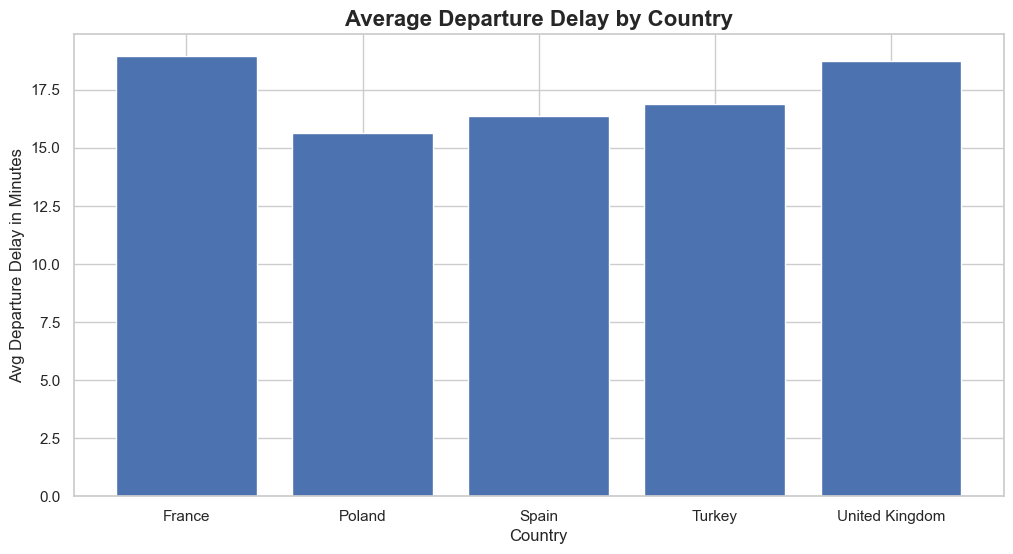

In [350]:
country_delay = df.groupby('Country')['Avg Departure Schedule Delay'].mean()

plt.figure()
plt.bar(country_delay.index, country_delay.values)
plt.title('Average Departure Delay by Country', fontsize=16, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Avg Departure Delay in Minutes')
plt.show()

UK and France show the highest average departure delays, while Poland consistently performs better.

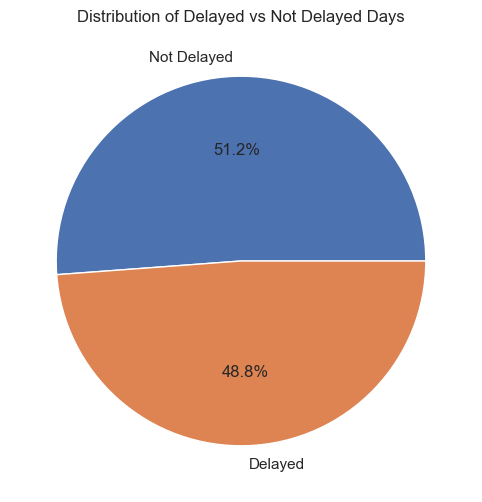

In [354]:
counts = df['Delayed'].value_counts()

plt.figure()
plt.pie(counts.values, labels=['Not Delayed', 'Delayed'], autopct='%1.1f%%')
plt.title('Distribution of Delayed vs Not Delayed Days')
plt.show()

The dataset shows a class balance, which is good for training the model.

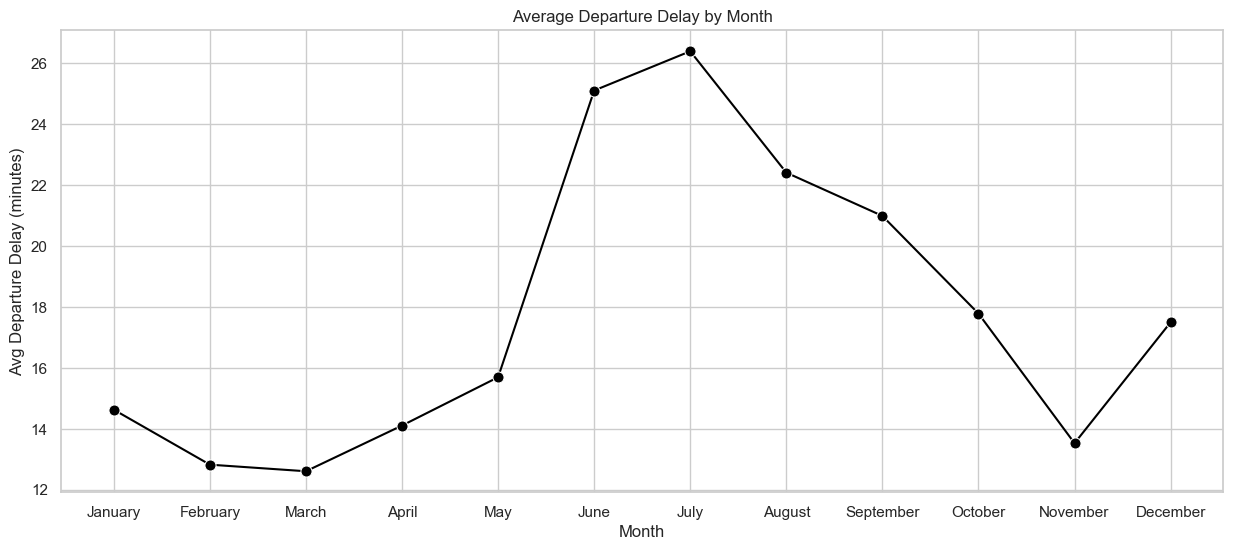

In [367]:
month_delay = df.groupby('Month')['Avg Departure Schedule Delay'].mean().reset_index()

month_names = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

plt.figure(figsize=(15, 6))
sns.lineplot(data=month_delay, x='Month', y='Avg Departure Schedule Delay', 
             marker='o', color='#000000', markersize=8)

plt.xticks(range(1, 13), month_names)
plt.title('Average Departure Delay by Month')
plt.xlabel('Month')
plt.ylabel('Avg Departure Delay (minutes)')
plt.show()

Delays is higher during summer months, likely caused by higher traffic volumes. December also show elevated delays due to bad weather conditions.

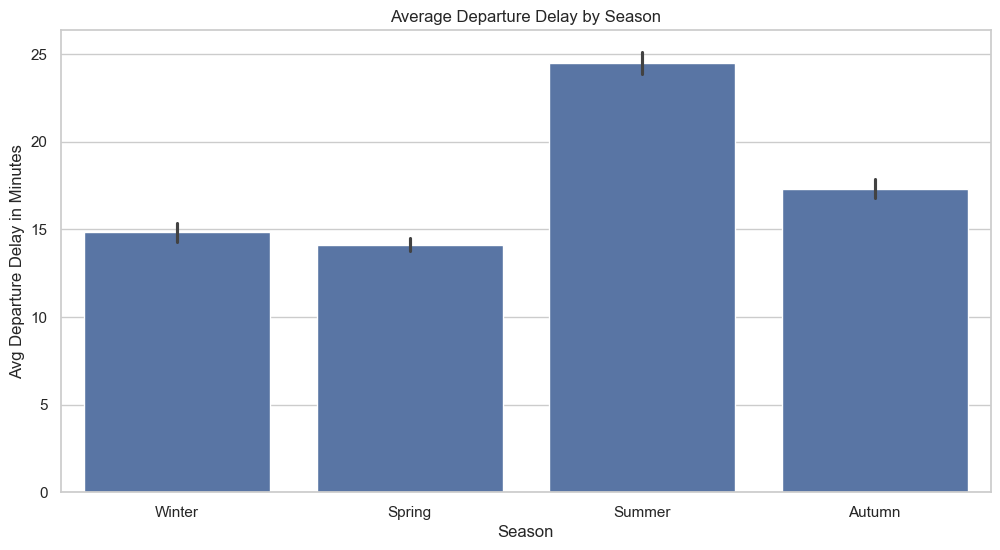

In [370]:
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

plt.figure()
sns.barplot(data=df, x='Season', y='Avg Departure Schedule Delay', order=season_order)
plt.title('Average Departure Delay by Season')
plt.xlabel('Season')
plt.ylabel('Avg Departure Delay in Minutes')
plt.show()

Summer shows the highest average delays, confirming that peak travel season puts significant pressure on airport operations. Autumn follow, while Spring and Winter tend to have the lowest delays.

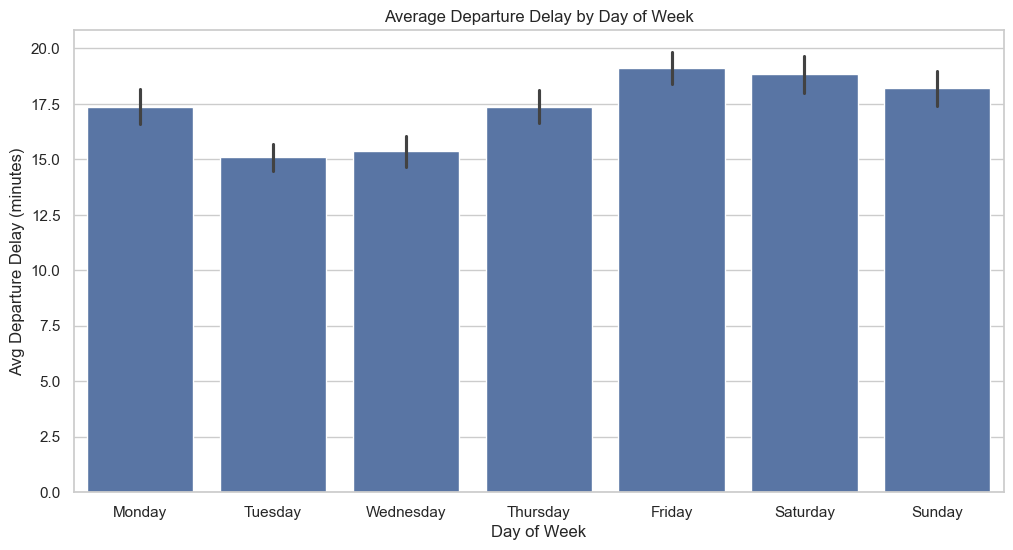

In [373]:
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure()
sns.barplot(data=df, x='Weekday', y='Avg Departure Schedule Delay', order=range(7))
plt.xticks(range(7), weekday_names)
plt.title('Average Departure Delay by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Avg Departure Delay (minutes)')
plt.show()

Weekends tend to show higher delays due to increased passenger volumes.

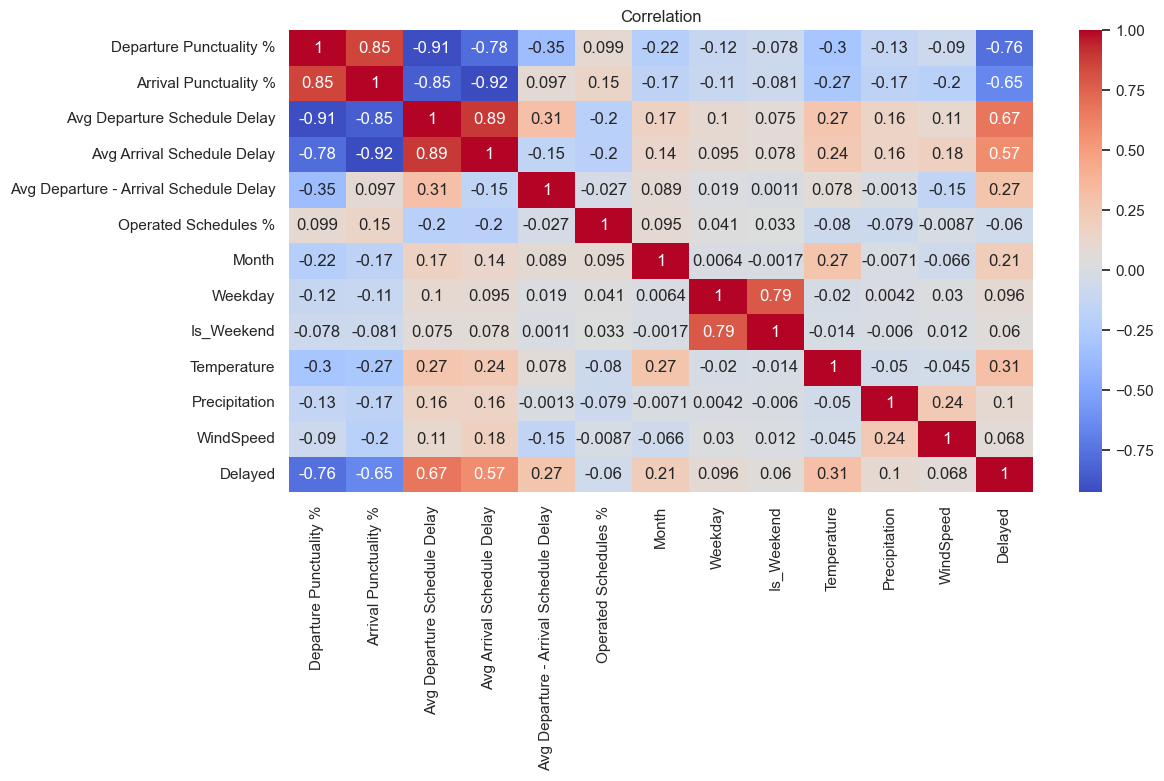

In [374]:
cor = df.corr(numeric_only=True)
sns.heatmap(cor, annot=True, cmap='coolwarm')
plt.title("Correlation")
plt.show()

The Delayed target variable shows the strongest correlation with departure delay and punctuality features.

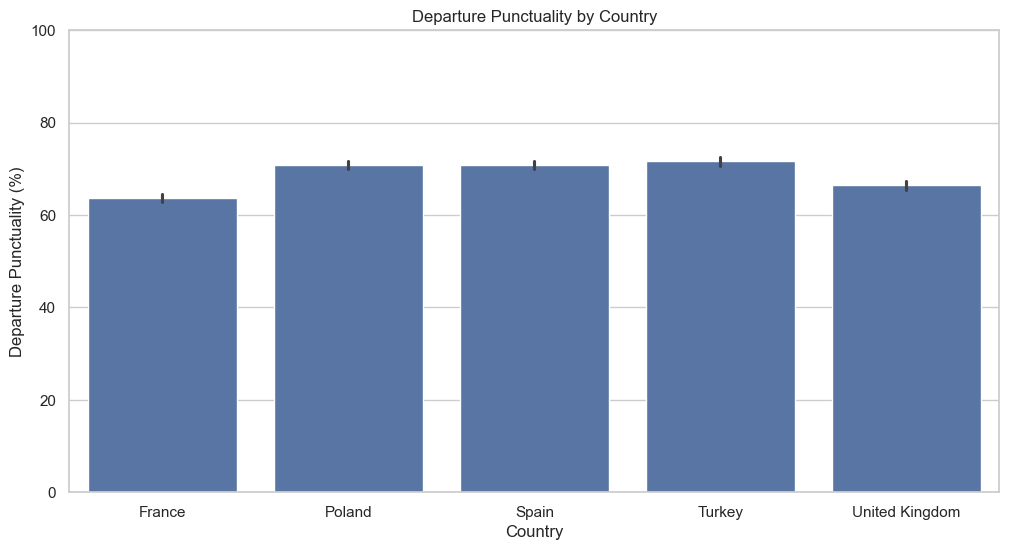

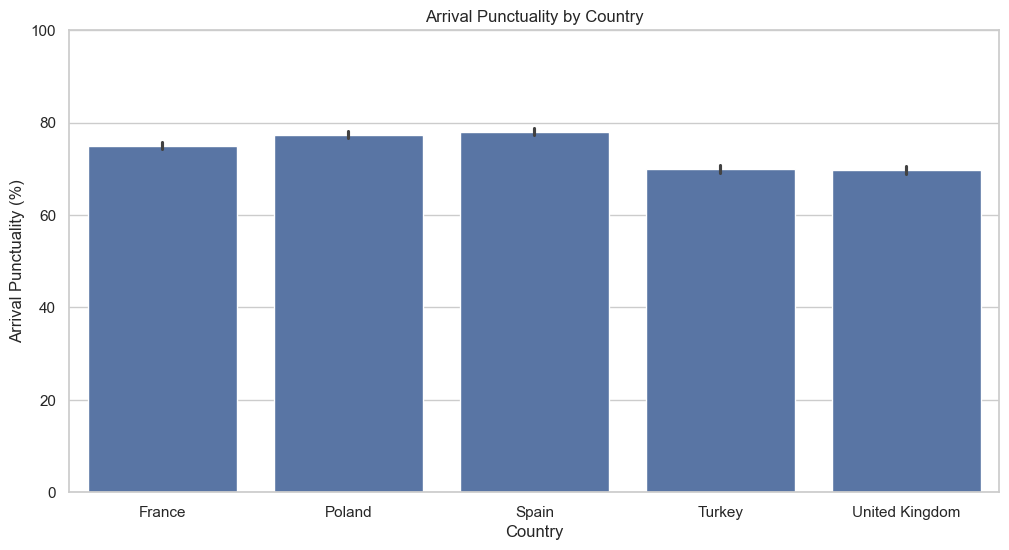

In [378]:
plt.figure()
sns.barplot(data=df, x='Country', y='Departure Punctuality %')
plt.title('Departure Punctuality by Country')
plt.xlabel('Country')
plt.ylabel('Departure Punctuality (%)')
plt.ylim(0, 100)
plt.show()

plt.figure()
sns.barplot(data=df, x='Country', y='Arrival Punctuality %')
plt.title('Arrival Punctuality by Country')
plt.xlabel('Country')
plt.ylabel('Arrival Punctuality (%)')
plt.ylim(0, 100)
plt.show()

Poland and Spain show relatively higher Punctuality compared to Turkey and UK. Across almost of the countries, arrival punctuality is generally slightly higher than departure punctuality.